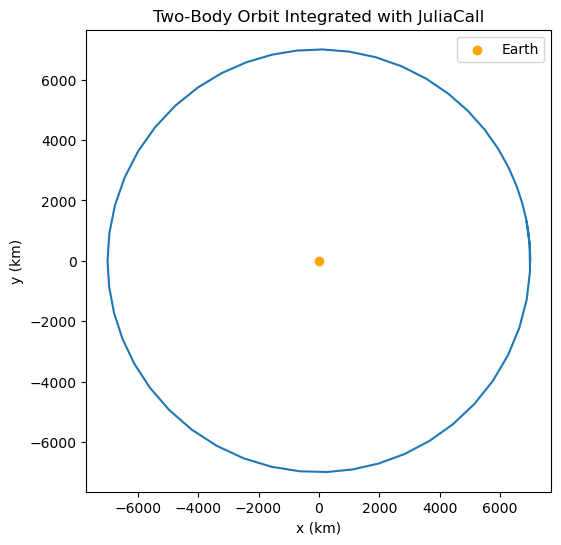

In [2]:
"""
orbit_solver.py

A fully self‑contained example showing how to use JuliaCall inside Python
to run high‑performance orbital dynamics using Julia’s DifferentialEquations.jl.

This module demonstrates the correct pattern for hybrid scientific workflows
where Python handles astronomy tools (Astropy, Lightkurve, FITS I/O, plotting)
and Julia handles numerics (ODE solving, orbital mechanics, stiff systems).

---------------------------------------------------------------------------
WHY USE JULIA FOR THE ODE INSTEAD OF PYTHON?
---------------------------------------------------------------------------

Python’s scientific ecosystem is excellent for astronomy, but its ODE solvers
(SciPy’s solve_ivp) are interpreted, slower, and less predictable for large or
stiff systems. Julia’s DifferentialEquations.jl is dramatically faster because:

1. Julia compiles ODE functions to optimized machine code.
2. Julia enforces type stability, preventing slow “Array{Any}” states.
3. Julia has world‑class ODE algorithms (Tsit5, Vern7, Rodas5P, Rosenbrock23).
4. Julia scales to large systems (N‑body, PDEs, stiff regimes) far better.
5. JuliaCall lets Python use Julia seamlessly without switching languages.

Thus, Python orchestrates the workflow, while Julia performs the heavy numerical
lifting — the best of both worlds.

---------------------------------------------------------------------------
WHAT THIS MODULE SHOWS
---------------------------------------------------------------------------

1. How JuliaCall initializes its own Julia environment inside a Conda env.
   - JuliaCall creates a private Julia project at:
       /opt/anaconda3/envs/py_juliacall/julia_env

2. How to install Julia packages into THAT environment (not global Julia).
   - DifferentialEquations.jl must be installed inside julia_env.

3. How to safely load Julia packages from Python.
   - Using jl.seval("using DifferentialEquations")

4. How to define a Julia ODE function directly from Python.
   - The two_body! function is injected into Julia’s Main module.

5. How to pass Python variables into Julia’s namespace.
   - jl.u0 = u0, jl.tspan = tspan, jl.μ_earth = μ_earth

6. How to ensure Julia receives concrete Float64 arrays (critical!).
   - u0 must be constructed as Float64[...] to avoid Array{Any} errors.

7. How to build and solve the ODE in Julia.
   - prob = ODEProblem(...)
   - sol = solve(prob, reltol=1e-9, abstol=1e-9)

8. How to retrieve Julia results back into Python.
   - JuliaCall converts Julia arrays → Python lists → NumPy arrays.

9. How to plot the orbit using Python’s matplotlib.
   - Python remains the visualization layer.

---------------------------------------------------------------------------
This hybrid pattern is ideal for astronomy pipelines:
- Python: FITS I/O, Lightkurve, Astropy, plotting, notebooks.
- Julia: ODE solving, orbital mechanics, N‑body, stiff systems.
---------------------------------------------------------------------------
"""


from juliacall import Main as jl
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# STEP 1 — Ensure JuliaCall is using the correct Julia environment
# ---------------------------------------------------------------------------
# JuliaCall creates a private Julia environment inside your Conda env:
#     /opt/anaconda3/envs/py_juliacall/julia_env
#
# You MUST install Julia packages into this environment, not global Julia.
# Otherwise "using DifferentialEquations" will fail.
#
# Run this once per environment creation:
#
# jl.seval("""
# import Pkg
# Pkg.activate("/opt/anaconda3/envs/py_juliacall/julia_env")
# Pkg.add("DifferentialEquations")
# Pkg.add("LinearAlgebra")
# Pkg.precompile()
# """)
#
# After that, JuliaCall will remember the environment.


# ---------------------------------------------------------------------------
# STEP 2 — Load Julia packages
# ---------------------------------------------------------------------------
# These must succeed before defining the ODE.
jl.seval("using DifferentialEquations")
jl.seval("using LinearAlgebra")


# ---------------------------------------------------------------------------
# STEP 3 — Define the two-body gravitational ODE in Julia
# ---------------------------------------------------------------------------
# This function lives inside Julia's Main module.
# JuliaCall allows us to define Julia code directly from Python.
jl.seval("""
function two_body!(du, u, p, t)
    # State vector u = [x, y, vx, vy]
    x, y, vx, vy = u
    r = sqrt(x^2 + y^2)
    μ = p  # gravitational parameter GM

    # Newtonian accelerations
    ax = -μ * x / r^3
    ay = -μ * y / r^3

    # Time derivatives
    du[1] = vx
    du[2] = vy
    du[3] = ax
    du[4] = ay
end
""")


# ---------------------------------------------------------------------------
# STEP 4 — Prepare initial conditions
# ---------------------------------------------------------------------------
# IMPORTANT:
# JuliaCall will convert Python floats into Julia Any unless we explicitly
# force a concrete type. DifferentialEquations.jl *requires* Float64 vectors.
#
# So we construct u0 using a Julia expression:
#
#     Float64[x0, y0, vx0, vy0]
#
# This guarantees a Vector{Float64}.
x0 = 7000.0
y0 = 0.0
vx0 = 0.0
vy0 = 7.546

u0 = jl.seval(f"Float64[{x0}, {y0}, {vx0}, {vy0}]")
jl.u0 = u0  # register in Julia's Main namespace


# ---------------------------------------------------------------------------
# STEP 5 — Define parameters and time span
# ---------------------------------------------------------------------------
μ_earth = 398600.0  # km^3/s^2
tspan = (0.0, 6000.0)

jl.μ_earth = μ_earth
jl.tspan = tspan


# ---------------------------------------------------------------------------
# STEP 6 — Build and solve the ODE in Julia
# ---------------------------------------------------------------------------
# ODEProblem(two_body!, u0, tspan, μ_earth)
prob = jl.seval("ODEProblem(two_body!, u0, tspan, μ_earth)")
jl.prob = prob  # make it visible to Julia

# Solve with tight tolerances
sol = jl.seval("solve(prob, reltol=1e-9, abstol=1e-9)")
jl.sol = sol


# ---------------------------------------------------------------------------
# STEP 7 — Convert Julia solution to Python arrays
# ---------------------------------------------------------------------------
# JuliaCall automatically converts Julia arrays to Python lists.
# We wrap them in NumPy arrays for plotting.
t = np.array(sol.t)
x = np.array([sol.u[i][0] for i in range(len(sol.u))])
y = np.array([sol.u[i][1] for i in range(len(sol.u))])


# ---------------------------------------------------------------------------
# STEP 8 — Plot the orbit using Python
# ---------------------------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.plot(x, y)
plt.scatter([0], [0], color="orange", label="Earth")
plt.xlabel("x (km)")
plt.ylabel("y (km)")
plt.title("Two‑Body Orbit Integrated with JuliaCall")
plt.axis("equal")
plt.legend()
plt.show()
